# 01 データ概要の確認

## 目的

ブロイラー鶏舎の自動計量システムから取得された時系列データについて、
データ量・列構成・データ型・欠損値・測定間隔などを確認し、
今後の前処理・分析方法を検討する。

## 確認項目

- データの行数・列数
- 各列の内容とデータ型
- 欠損値
- penの種類
- mass[kg]の分布
- datetimeの範囲
- 測定間隔
- trial1 / trial2 の違い

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Notebookから見たプロジェクトルート
PROJECT_ROOT = Path("..")

file_path = PROJECT_ROOT / "data" / "raw" / "trial1" / "2019-06-19.csv"

df = pd.read_csv(file_path)

df.head()

,datetime,order,pen,mass[kg]
0,2019-06-19T07:22:35,0,1,0.03
1,2019-06-19T07:22:35,1,1,0.03
2,2019-06-19T07:22:35,0,2,-0.23
3,2019-06-19T07:22:35,1,2,-0.23
4,2019-06-19T07:22:35,0,3,-0.39


In [2]:
print("データサイズ:", df.shape)
print("\n列名:")
print(df.columns.tolist())

print("\nデータ型:")
print(df.dtypes)

print("\n欠損値:")
print(df.isnull().sum())

データサイズ: (1640445, 4)

列名:
['datetime', 'order', 'pen', 'mass[kg]']

データ型:
datetime        str
order         int64
pen           int64
mass[kg]    float64
dtype: object

欠損値:
datetime    0
order       0
pen         0
mass[kg]    0
dtype: int64


In [3]:
print("penの種類:", sorted(df["pen"].unique()))

print("\nmass[kg] 基本統計量:")
display(df["mass[kg]"].describe())

penの種類: [np.int64(1), np.int64(2), np.int64(3)]

mass[kg] 基本統計量:


count    1.640445e+06
mean    -1.952007e-01
std      1.960802e+00
min     -5.200000e-01
25%     -3.100000e-01
50%     -2.500000e-01
75%     -2.100000e-01
max      8.215000e+01
Name: mass[kg], dtype: float64

In [4]:
df["datetime"] = pd.to_datetime(df["datetime"])

print("開始:", df["datetime"].min())
print("終了:", df["datetime"].max())
print("ユニークな時刻数:", df["datetime"].nunique())

開始: 2019-06-19 07:22:35
終了: 2019-06-19 23:59:59
ユニークな時刻数: 59845


In [5]:
pen_counts = df["pen"].value_counts().sort_index()

print("penごとのデータ件数:")
display(pen_counts)

penごとのデータ件数:


pen
1    546957
2    546949
3    546539
Name: count, dtype: int64

In [6]:
pen_stats = df.groupby("pen")["mass[kg]"].describe()

display(pen_stats)

,count,mean,std,min,25%,50%,75%,max
pen,,,,,,,,
1,546957.0,-0.083868,3.391616,-0.43,-0.33,-0.30,-0.27,82.15
2,546949.0,-0.225954,0.035866,-0.37,-0.24,-0.22,-0.20,-0.13
3,546539.0,-0.275842,0.084102,-0.52,-0.32,-0.27,-0.21,-0.05


In [7]:
print("mass[kg] が大きいデータ:")
display(
    df.nlargest(20, "mass[kg]")
)

mass[kg] が大きいデータ:


,datetime,order,pen,mass[kg]
344008,2019-06-19 10:51:47,2,1,82.15
344310,2019-06-19 10:51:58,2,1,81.94
344282,2019-06-19 10:51:57,1,1,81.58
344281,2019-06-19 10:51:57,0,1,80.98
344007,2019-06-19 10:51:47,1,1,80.94
344009,2019-06-19 10:51:47,3,1,80.87
343109,2019-06-19 10:51:14,8,1,80.80
344311,2019-06-19 10:51:58,3,1,80.68
344283,2019-06-19 10:51:57,2,1,80.57
341628,2019-06-19 10:50:20,8,1,80.39


In [8]:
for threshold in [0, 1, 5, 10, 20, 50]:
    count = (df["mass[kg]"] > threshold).sum()
    print(f"{threshold} kg超: {count:,}件")

0 kg超: 90,412件
1 kg超: 1,170件
5 kg超: 1,168件
10 kg超: 1,166件
20 kg超: 1,161件
50 kg超: 1,143件


In [9]:
# 10kgを超えるデータの発生状況を確認
high_mass = df[df["mass[kg]"] > 10].copy()

print("件数:", len(high_mass))
print("開始:", high_mass["datetime"].min())
print("終了:", high_mass["datetime"].max())

print("\npen別件数:")
display(high_mass["pen"].value_counts().sort_index())

件数: 1166
開始: 2019-06-19 10:50:08
終了: 2019-06-19 10:56:06

pen別件数:


pen
1    1166
Name: count, dtype: int64

In [10]:
# 10:45～11:00のpen 1だけ抽出
check_period = df[
    (df["pen"] == 1) &
    (df["datetime"] >= "2019-06-19 10:45:00") &
    (df["datetime"] <= "2019-06-19 11:00:00")
].copy()

display(check_period.head())
display(check_period.tail())

print(check_period["mass[kg]"].describe())

,datetime,order,pen,mass[kg]
332846,2019-06-19 10:45:00,0,1,0.0
332847,2019-06-19 10:45:00,1,1,0.0
332848,2019-06-19 10:45:00,2,1,0.0
332849,2019-06-19 10:45:00,3,1,0.0
332850,2019-06-19 10:45:00,4,1,0.0


,datetime,order,pen,mass[kg]
357532,2019-06-19 11:00:00,4,1,-0.39
357533,2019-06-19 11:00:00,5,1,-0.39
357534,2019-06-19 11:00:00,6,1,-0.39
357535,2019-06-19 11:00:00,7,1,-0.39
357536,2019-06-19 11:00:00,8,1,-0.39


count    8237.000000
mean       10.124440
std        25.628287
min        -0.430000
25%        -0.390000
50%        -0.370000
75%         0.000000
max        82.150000
Name: mass[kg], dtype: float64


In [11]:
# 異常区間前後のpen 1を抽出
plot_data = df[
    (df["pen"] == 1) &
    (df["datetime"] >= "2019-06-19 10:48:00") &
    (df["datetime"] <= "2019-06-19 10:58:00")
].copy()

# 1秒ごとの最大値に集約
plot_data["second"] = plot_data["datetime"].dt.floor("s")

plot_sec = (
    plot_data
    .groupby("second")["mass[kg]"]
    .max()
    .reset_index()
)

print("集約後の件数:", len(plot_sec))
display(plot_sec.head())

集約後の件数: 601


,second,mass[kg]
0,2019-06-19 10:48:00,-0.01
1,2019-06-19 10:48:01,-0.01
2,2019-06-19 10:48:02,-0.01
3,2019-06-19 10:48:03,-0.02
4,2019-06-19 10:48:04,-0.02


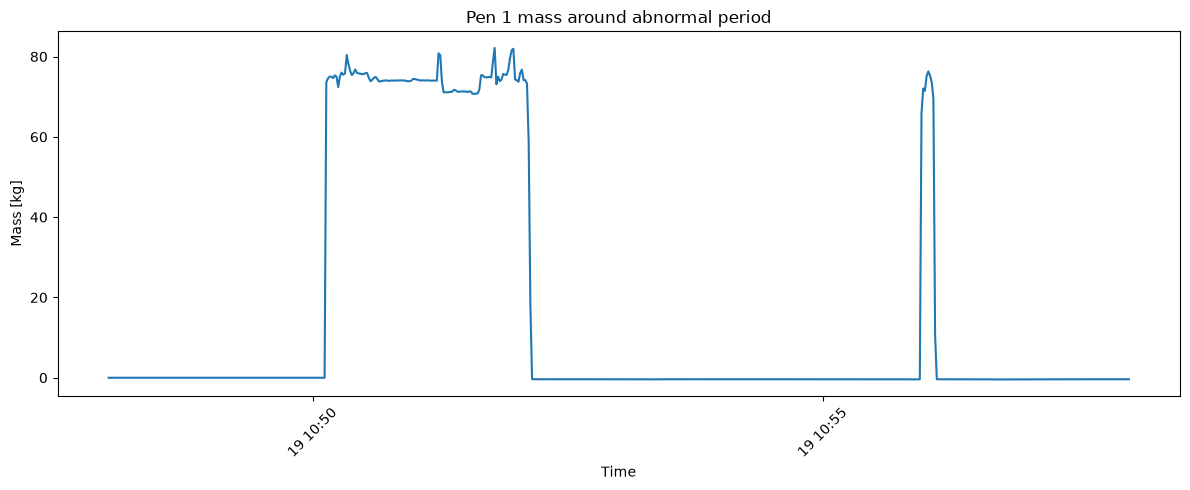

In [12]:
plt.figure(figsize=(12, 5))

plt.plot(
    plot_sec["second"],
    plot_sec["mass[kg]"]
)

plt.xlabel("Time")
plt.ylabel("Mass [kg]")
plt.title("Pen 1 mass around abnormal period")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [13]:
from pathlib import Path

trial1_dir = PROJECT_ROOT / "data" / "raw" / "trial1"
trial2_dir = PROJECT_ROOT / "data" / "raw" / "trial2"

trial1_files = sorted(trial1_dir.glob("*.csv"))
trial2_files = sorted(trial2_dir.glob("*.csv"))

print("trial1:", len(trial1_files), "ファイル")
print("trial2:", len(trial2_files), "ファイル")

print("\ntrial1 最初:", trial1_files[0].name)
print("trial1 最後:", trial1_files[-1].name)

print("\ntrial2 最初:", trial2_files[0].name)
print("trial2 最後:", trial2_files[-1].name)

trial1: 34 ファイル
trial2: 36 ファイル

trial1 最初: 2019-06-19.csv
trial1 最後: 2019-07-22.csv

trial2 最初: 2019-09-09.csv
trial2 最後: 2019-10-14.csv


In [14]:
summary_list = []

for file in trial1_files:
    print("処理中:", file.name)

    temp = pd.read_csv(file)

    # 日付をファイル名から取得
    date = file.stem

    # penごとに集計
    stats = (
        temp.groupby("pen")["mass[kg]"]
        .agg(
            count="count",
            min_mass="min",
            median_mass="median",
            max_mass="max"
        )
        .reset_index()
    )

    # 10kgを超える測定値の件数
    over_10 = (
        temp[temp["mass[kg]"] > 10]
        .groupby("pen")
        .size()
        .rename("over_10kg")
        .reset_index()
    )

    stats = stats.merge(over_10, on="pen", how="left")
    stats["over_10kg"] = stats["over_10kg"].fillna(0).astype(int)

    stats.insert(0, "date", date)

    summary_list.append(stats)

trial1_summary = pd.concat(summary_list, ignore_index=True)

display(trial1_summary.head(10))
print("集計後:", trial1_summary.shape)

処理中: 2019-06-19.csv
処理中: 2019-06-20.csv
処理中: 2019-06-21.csv
処理中: 2019-06-22.csv
処理中: 2019-06-23.csv
処理中: 2019-06-24.csv
処理中: 2019-06-25.csv
処理中: 2019-06-26.csv
処理中: 2019-06-27.csv
処理中: 2019-06-28.csv
処理中: 2019-06-29.csv
処理中: 2019-06-30.csv
処理中: 2019-07-01.csv
処理中: 2019-07-02.csv
処理中: 2019-07-03.csv
処理中: 2019-07-04.csv
処理中: 2019-07-05.csv
処理中: 2019-07-06.csv
処理中: 2019-07-07.csv
処理中: 2019-07-08.csv
処理中: 2019-07-09.csv
処理中: 2019-07-10.csv
処理中: 2019-07-11.csv
処理中: 2019-07-12.csv
処理中: 2019-07-13.csv
処理中: 2019-07-14.csv
処理中: 2019-07-15.csv
処理中: 2019-07-16.csv
処理中: 2019-07-17.csv
処理中: 2019-07-18.csv
処理中: 2019-07-19.csv
処理中: 2019-07-20.csv
処理中: 2019-07-21.csv
処理中: 2019-07-22.csv


,date,pen,count,min_mass,median_mass,max_mass,over_10kg
0,2019-06-19,1,546957,-0.43,-0.30,82.15,1166
1,2019-06-19,2,546949,-0.37,-0.22,-0.13,0
2,2019-06-19,3,546539,-0.52,-0.27,-0.05,0
3,2019-06-20,1,789613,-0.47,-0.34,-0.10,0
4,2019-06-20,2,789672,-0.41,-0.25,-0.08,0
5,2019-06-20,3,788927,-0.68,-0.49,0.40,0
6,2019-06-21,1,789646,-0.47,-0.23,0.82,0
7,2019-06-21,2,789707,-0.41,-0.29,0.21,0
8,2019-06-21,3,789062,-0.83,-0.50,1.08,0
9,2019-06-22,1,789699,-0.33,-0.12,1.73,0


集計後: (102, 7)


In [15]:
trial1_summary.to_csv(
    PROJECT_ROOT / "data" / "interim" / "trial1_daily_quality_summary.csv",
    index=False
)

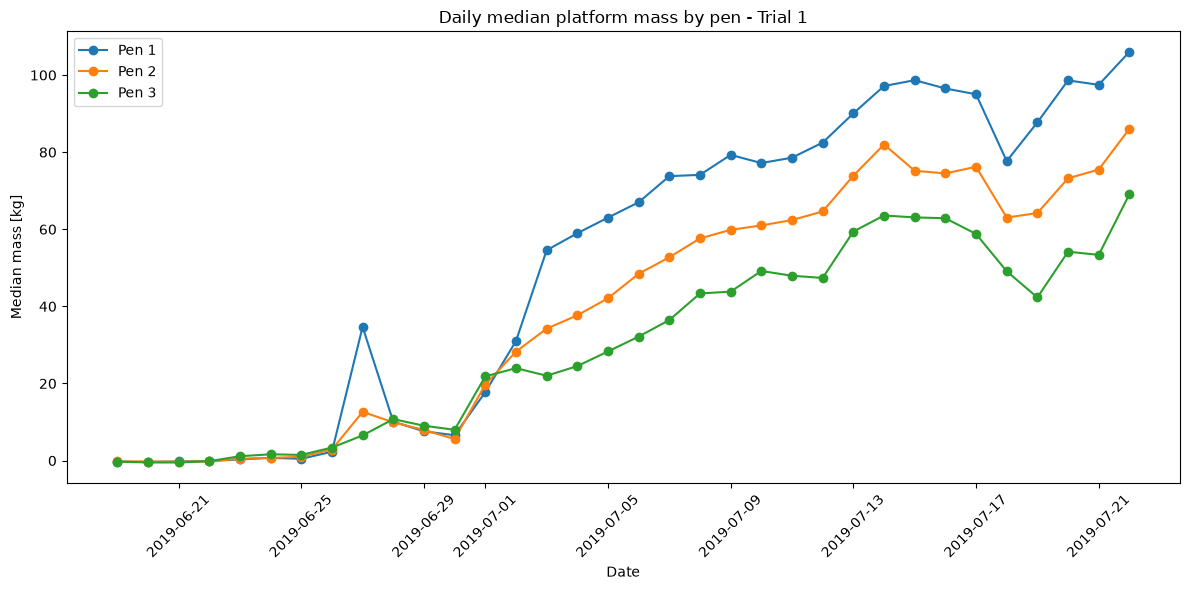

In [16]:
trial1_summary["date"] = pd.to_datetime(trial1_summary["date"])

plt.figure(figsize=(12, 6))

for pen in sorted(trial1_summary["pen"].unique()):
    pen_data = trial1_summary[trial1_summary["pen"] == pen]

    plt.plot(
        pen_data["date"],
        pen_data["median_mass"],
        marker="o",
        label=f"Pen {pen}"
    )

plt.xlabel("Date")
plt.ylabel("Median mass [kg]")
plt.title("Daily median platform mass by pen - Trial 1")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
trial1_summary = trial1_summary.sort_values(["pen", "date"])

trial1_summary["median_change"] = (
    trial1_summary
    .groupby("pen")["median_mass"]
    .diff()
)

display(
    trial1_summary[
        ["date", "pen", "median_mass", "median_change"]
    ]
    .sort_values("median_change")
    .head(15)
)

,date,pen,median_mass,median_change
27,2019-06-28,1,10.10,-24.57
87,2019-07-18,1,77.69,-17.33
88,2019-07-18,2,63.04,-13.17
89,2019-07-18,3,49.11,-9.68
79,2019-07-15,2,75.18,-6.81
92,2019-07-19,3,42.31,-6.80
86,2019-07-17,3,58.79,-4.07
28,2019-06-28,2,9.92,-2.71
30,2019-06-29,1,7.59,-2.51
34,2019-06-30,2,5.58,-2.37


In [18]:
display(
    trial1_summary[
        ["date", "pen", "median_mass", "median_change"]
    ]
    .sort_values("median_change", ascending=False)
    .head(15)
)

,date,pen,median_mass,median_change
24,2019-06-27,1,34.67,32.38
42,2019-07-03,1,54.55,23.55
101,2019-07-22,3,69.10,15.74
37,2019-07-01,2,19.71,14.13
38,2019-07-01,3,21.84,13.86
39,2019-07-02,1,31.00,13.25
74,2019-07-13,3,59.41,12.03
95,2019-07-20,3,54.18,11.87
36,2019-07-01,1,17.75,11.18
93,2019-07-20,1,98.62,10.90


In [19]:
def create_daily_summary(files):
    summary_list = []

    for file in files:
        print("処理中:", file.name)

        # CSV読み込み
        temp = pd.read_csv(file)

        # ファイル名から日付を取得
        date = file.stem

        # penごとの基本統計量
        stats = (
            temp.groupby("pen")["mass[kg]"]
            .agg(
                count="count",
                min_mass="min",
                median_mass="median",
                max_mass="max"
            )
            .reset_index()
        )

        # 10kg超の件数
        over_10 = (
            temp[temp["mass[kg]"] > 10]
            .groupby("pen")
            .size()
            .rename("over_10kg")
            .reset_index()
        )

        # 基本統計量と10kg超件数を結合
        stats = stats.merge(over_10, on="pen", how="left")
        stats["over_10kg"] = stats["over_10kg"].fillna(0).astype(int)

        # 日付を追加
        stats.insert(0, "date", date)

        summary_list.append(stats)

    # 全日分を1つのDataFrameに結合
    summary = pd.concat(summary_list, ignore_index=True)

    # 日付型に変換
    summary["date"] = pd.to_datetime(summary["date"])

    return summary

In [20]:
trial1_summary = create_daily_summary(trial1_files)

print("trial1:", trial1_summary.shape)
display(trial1_summary.head())

処理中: 2019-06-19.csv
処理中: 2019-06-20.csv
処理中: 2019-06-21.csv
処理中: 2019-06-22.csv
処理中: 2019-06-23.csv
処理中: 2019-06-24.csv
処理中: 2019-06-25.csv
処理中: 2019-06-26.csv
処理中: 2019-06-27.csv
処理中: 2019-06-28.csv
処理中: 2019-06-29.csv
処理中: 2019-06-30.csv
処理中: 2019-07-01.csv
処理中: 2019-07-02.csv
処理中: 2019-07-03.csv
処理中: 2019-07-04.csv
処理中: 2019-07-05.csv
処理中: 2019-07-06.csv
処理中: 2019-07-07.csv
処理中: 2019-07-08.csv
処理中: 2019-07-09.csv
処理中: 2019-07-10.csv
処理中: 2019-07-11.csv
処理中: 2019-07-12.csv
処理中: 2019-07-13.csv
処理中: 2019-07-14.csv
処理中: 2019-07-15.csv
処理中: 2019-07-16.csv
処理中: 2019-07-17.csv
処理中: 2019-07-18.csv
処理中: 2019-07-19.csv
処理中: 2019-07-20.csv
処理中: 2019-07-21.csv
処理中: 2019-07-22.csv
trial1: (102, 7)


,date,pen,count,min_mass,median_mass,max_mass,over_10kg
0,2019-06-19,1,546957,-0.43,-0.30,82.15,1166
1,2019-06-19,2,546949,-0.37,-0.22,-0.13,0
2,2019-06-19,3,546539,-0.52,-0.27,-0.05,0
3,2019-06-20,1,789613,-0.47,-0.34,-0.10,0
4,2019-06-20,2,789672,-0.41,-0.25,-0.08,0


In [21]:
trial2_summary = create_daily_summary(trial2_files)

print("trial2:", trial2_summary.shape)
display(trial2_summary.head())

処理中: 2019-09-09.csv
処理中: 2019-09-10.csv
処理中: 2019-09-11.csv
処理中: 2019-09-12.csv
処理中: 2019-09-13.csv
処理中: 2019-09-14.csv
処理中: 2019-09-15.csv
処理中: 2019-09-16.csv
処理中: 2019-09-17.csv
処理中: 2019-09-18.csv
処理中: 2019-09-19.csv
処理中: 2019-09-20.csv
処理中: 2019-09-21.csv
処理中: 2019-09-22.csv
処理中: 2019-09-23.csv
処理中: 2019-09-24.csv
処理中: 2019-09-25.csv
処理中: 2019-09-26.csv
処理中: 2019-09-27.csv
処理中: 2019-09-28.csv
処理中: 2019-09-29.csv
処理中: 2019-09-30.csv
処理中: 2019-10-01.csv
処理中: 2019-10-02.csv
処理中: 2019-10-03.csv
処理中: 2019-10-04.csv
処理中: 2019-10-05.csv
処理中: 2019-10-06.csv
処理中: 2019-10-07.csv
処理中: 2019-10-08.csv
処理中: 2019-10-09.csv
処理中: 2019-10-10.csv
処理中: 2019-10-11.csv
処理中: 2019-10-12.csv
処理中: 2019-10-13.csv
処理中: 2019-10-14.csv
trial2: (107, 7)


,date,pen,count,min_mass,median_mass,max_mass,over_10kg
0,2019-09-09,1,773,0.04,0.04,0.05,0
1,2019-09-09,2,364701,-0.13,-0.10,0.01,0
2,2019-09-09,3,357071,-0.15,-0.11,0.16,0
3,2019-09-10,1,606604,-0.37,-0.19,8.12,0
4,2019-09-10,2,841123,-0.20,-0.09,0.05,0


In [22]:
# trial2でpenが3種類そろっていない日を確認
pen_count_by_date = (
    trial2_summary
    .groupby("date")["pen"]
    .nunique()
)

print("penが3種類そろっていない日:")
display(pen_count_by_date[pen_count_by_date < 3])

penが3種類そろっていない日:


date
2019-10-03    2
Name: pen, dtype: int64

In [23]:
daily_count = (
    trial2_summary
    .groupby("date")["count"]
    .sum()
    .sort_values()
)

display(daily_count.head(10))

date
2019-09-09     722545
2019-10-14    1008666
2019-10-03    1685026
2019-10-02    2038920
2019-10-04    2062348
2019-09-27    2242257
2019-09-29    2247911
2019-09-26    2249931
2019-09-28    2256515
2019-09-25    2268666
Name: count, dtype: int64

In [24]:
display(
    trial2_summary[
        trial2_summary["date"] == "2019-10-03"
    ]
)

,date,pen,count,min_mass,median_mass,max_mass,over_10kg
72,2019-10-03,1,821471,8.67,50.81,67.63,821353
73,2019-10-03,3,863555,20.25,46.08,72.37,863555


確認結果
Trial 2は36日分のデータがあるが、2019-10-03はPen 2のデータが存在せず、Pen 1・Pen 3のみだった。そのため、日×pen単位の集計結果は108行ではなく107行となった。
また、初日や最終日は通常日より測定件数が少なく、日によってデータ量に差があることを確認した。

In [25]:
def plot_daily_median(summary, trial_name):
    plt.figure(figsize=(12, 6))

    for pen in sorted(summary["pen"].unique()):
        pen_data = summary[summary["pen"] == pen]

        plt.plot(
            pen_data["date"],
            pen_data["median_mass"],
            marker="o",
            label=f"Pen {pen}"
        )

    plt.xlabel("Date")
    plt.ylabel("Median mass [kg]")
    plt.title(f"Daily median platform mass by pen - {trial_name}")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

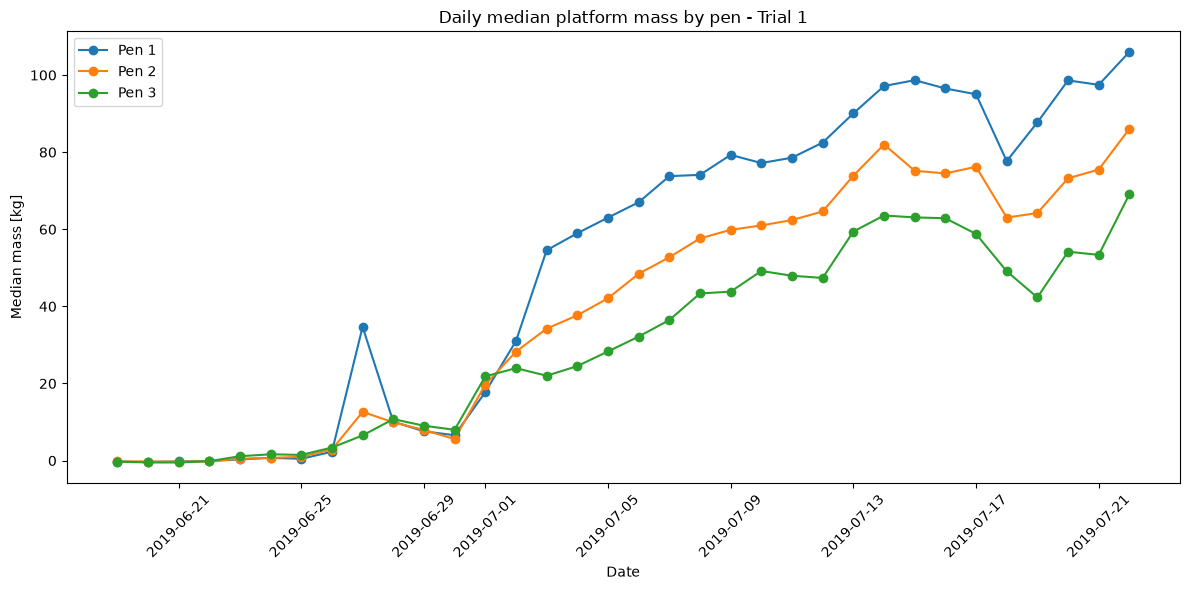

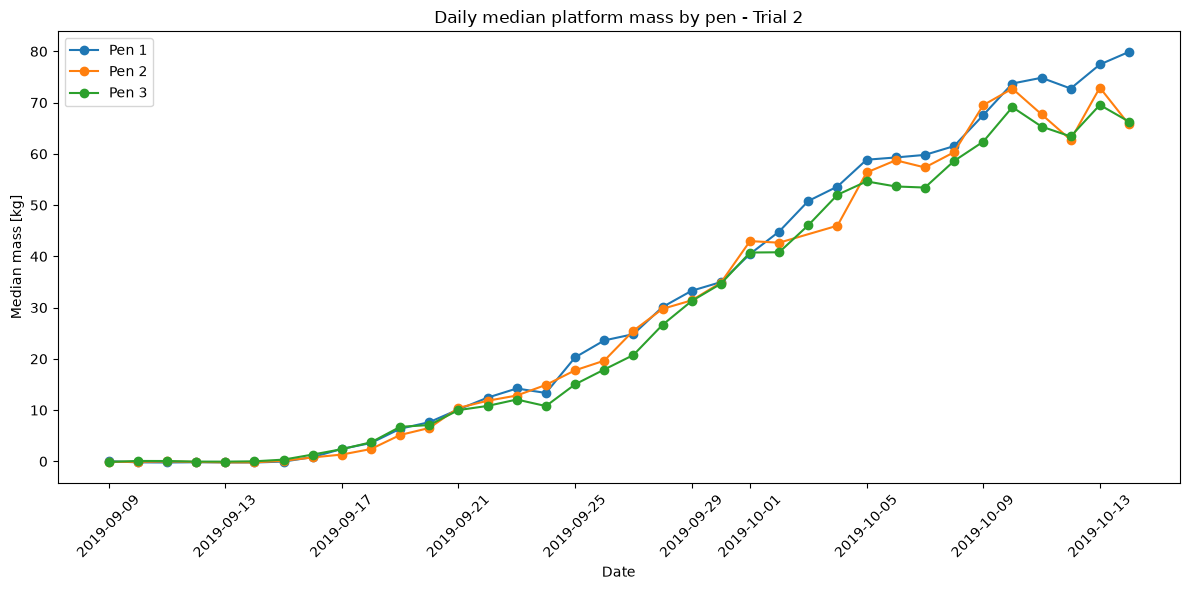

In [26]:
plot_daily_median(trial1_summary, "Trial 1")
plot_daily_median(trial2_summary, "Trial 2")

## データ概要の確認結果

### Trial 1
- 2019-06-19〜2019-07-22の34日分のデータを確認した。
- Pen 1〜3のいずれも、期間の経過とともにmassの中央値が上昇する傾向がみられた。
- Penごとの値には差があり、Pen 1が比較的高く、Pen 3が低い傾向がみられた。
- 一部の日では中央値が急激に上昇・低下しており、日ごとの変動も確認された。

### Trial 2
- 2019-09-09〜2019-10-14の36日分のデータを確認した。
- Trial 1と同様に、期間の経過とともにmassの中央値が上昇した。
- Trial 1と比較すると、3つのPenが比較的近い推移を示した。
- 2019-10-03はPen 2のデータが存在せず、日×Pen単位の集計結果は108行ではなく107行となった。
- 初日・最終日など、一部の日では測定件数が通常日より少ないことを確認した。

### 今後の分析
Trial 1・Trial 2の両方でmassの増加傾向が確認できたため、
今後は日ごとのmassの変化やPen間の違いを整理し、
鶏群の成長傾向を把握できる指標の作成を進める。